# ControlNet with Stable Diffusion using Canny images

Welcome to this interactive guide on Stable Diffusion + ControlNet!

In this Google Colab, we’re moving beyond simple text-to-image generation. While standard Stable Diffusion is great for creative exploration, when you want a specific composition or pose it's hard to obtain. That’s where ControlNet comes in.

ControlNet is a neural network structure to control diffusion models by adding extra conditions. Instead of relying solely on a text prompt, ControlNet allows you to feed the model an extra piece of visual information to guide the structure of the output. This checkpoint corresponds to the ControlNet **conditioned on Canny edges** (this technique extracts the edges from a reference image, creating a high-contrast wireframe.).

ControlNet can be used in combination with Stable Diffusion.

## Requirements

In [1]:
pip install diffusers transformers accelerate

In [2]:
pip install opencv-contrib-python

In [3]:
import cv2
from PIL import Image
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel, UniPCMultistepScheduler
import torch
import numpy as np
from diffusers.utils import load_image
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


## Import image

Firstly, we download the image and apply the Canny edge detector. It will be passed to our model to condition the output

In [4]:
image = load_image("output_bird_canny.png")
image = np.array(image)
original_img = image

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
image = Image.fromarray(image)

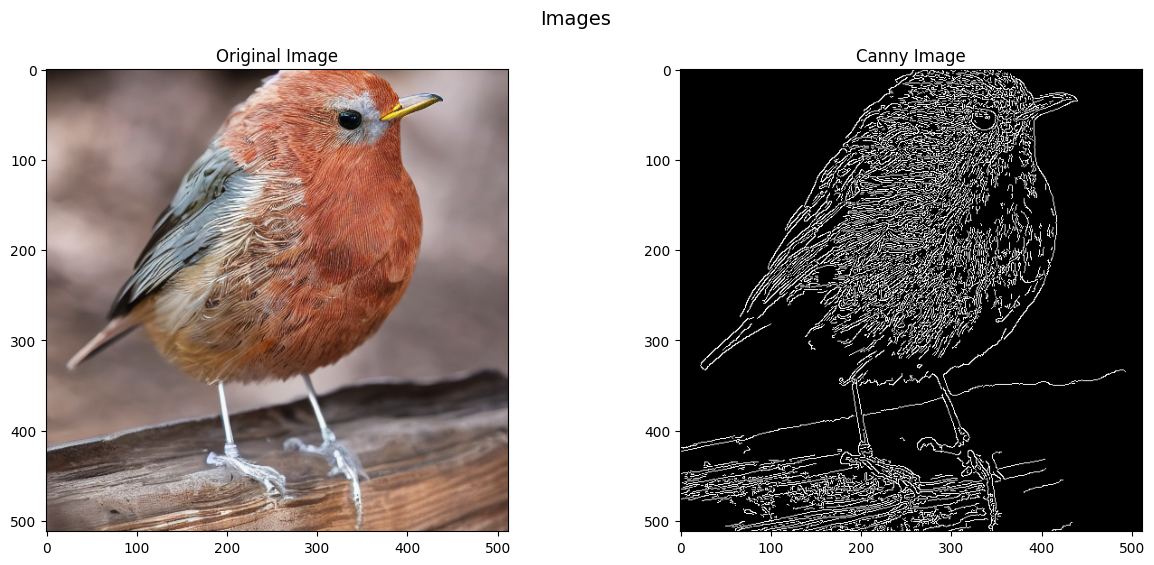

In [5]:
plt.figure(figsize=(15,6))
plt.suptitle('Images', fontsize=14)

plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(original_img)

plt.subplot(1, 2, 2)
plt.title('Canny Image')
plt.imshow(image)

## Model

The **ControlNet** + **Stable Diffusion v1-5** model to control SD using canny edge detection.

It's recommended to use the checkpoint with Stable Diffusion v1-5 as the checkpoint has been trained on it. Experimentally, the checkpoint can be used with other diffusion models such as dreamboothed stable diffusion.

**UniPCMultistepScheduler** is a training-free framework designed for fast sampling of diffusion models

In [6]:
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny", torch_dtype=torch.float16
)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", controlnet=controlnet, safety_checker=None, torch_dtype=torch.float16
)

pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)

# Remove if you do not have xformers installed
# see https://huggingface.co/docs/diffusers/v0.13.0/en/optimization/xformers#installing-xformers
# for installation instructions
#pipe.enable_xformers_memory_efficient_attention()

pipe.enable_model_cpu_offload()

image = pipe("bird", image, num_inference_steps=30).images[0]

#image.save('images/bird_canny_out.png')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results

  0%|          | 0/30 [00:00<?, ?it/s]

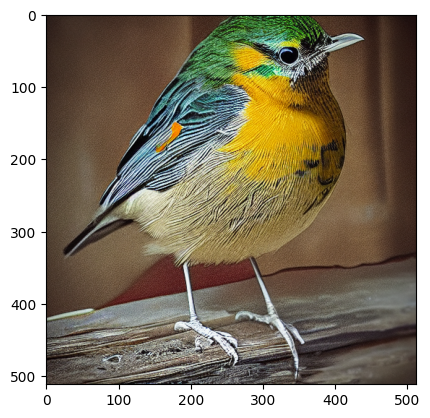

In [7]:
plt.imshow(image)

## Bibliography

- **ControlNet with Stable Diffusion**: https://huggingface.co/lllyasviel/sd-controlnet-canny
- **ControlNet blog**: https://huggingface.co/blog/controlnet